# Lab IV: Linear Models
### Answer all three sets of questions

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
    
    A model is considered linear if the output is a linear combination of the inputs and the coefficients. It is linear in the relationship

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
    
    After making one of the dummy variables your reference category, the coefficients for dummy variables represent the expected difference between that variable and the reference category. 

3. Can linear regression be used for classification? Explain why, or why not.
    
    Technically, yes, because you could set thresholds or "bins" on your dependent variable to create categories. That said, there are better options for classifications.

4. If you have a high accuracy on training but low on testing, what might be the problem? It's also possible you'll see a pattern in the residuals. 
    
    Overfitting sounds like it's the problem here! Perhaps your train test split was not the right ratio.

5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
    
    Polynomial regression and binned regression.

6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
    
    The intercept is what you would expect Y variable to be given that the reference variable is true and all other variables are zero.
    The slope coefficient for a variable is the expected change in Y per unit of X
    The coefficient for a dummy variable is how much on average Y varies from one category to the reference category.

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [96]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [97]:
houses = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
houses.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


###  1.1 Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

In [98]:
nhoods = houses.groupby('Neighbourhood ').agg({
    'Price': 'mean',
    'Review Scores Rating': 'mean'
})

print(nhoods)

                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750


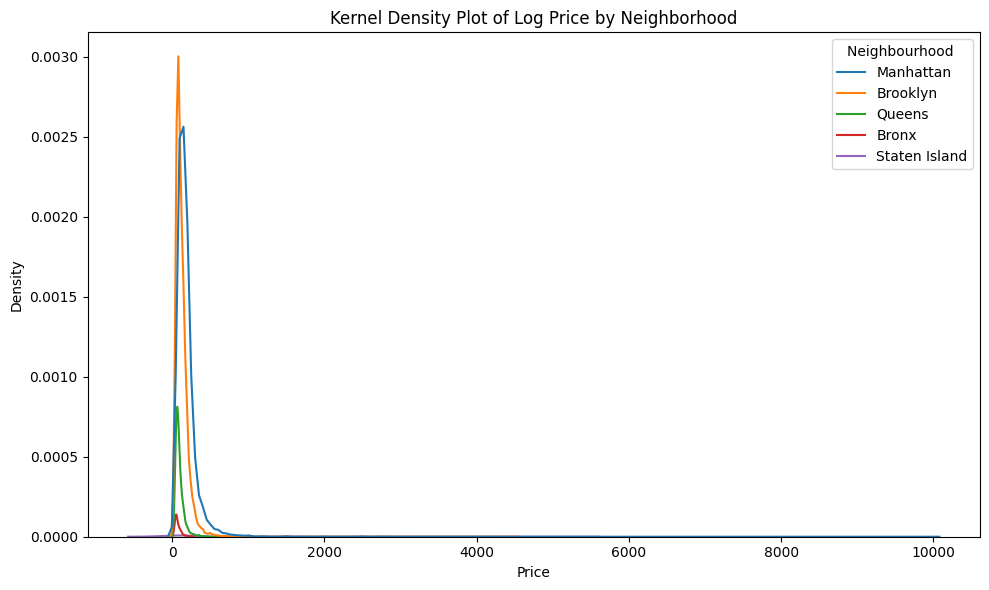

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Kernel density plot for price
sns.kdeplot(data=houses, x='Price', hue='Neighbourhood ')
plt.title('Kernel Density Plot of Price by Neighborhood')

# Show the plot
plt.tight_layout()
plt.show()

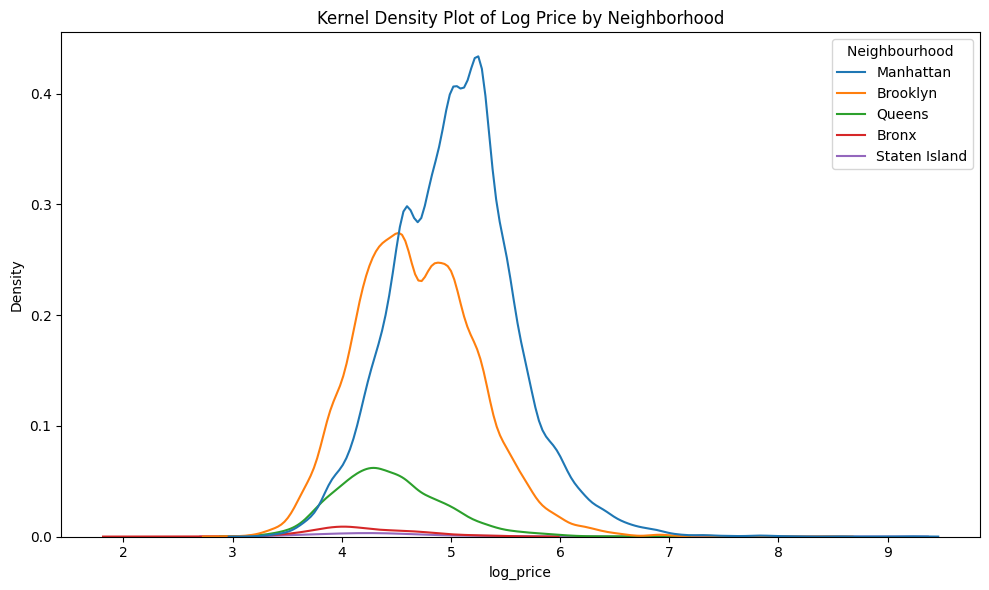

In [100]:
# Calculate log(price)
houses['log_price'] = np.log(houses['Price'])

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Kernel density plot for log(price)
sns.kdeplot(data=houses, x='log_price', hue='Neighbourhood ')
plt.title('Kernel Density Plot of Log Price by Neighborhood')

# Show the plot
plt.tight_layout()
plt.show()

Manhattan is the most expensive burrow on average.

### 1.2 Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [101]:
from sklearn.linear_model import LinearRegression

In [102]:
houses['Neighbourhood '] = houses['Neighbourhood '].astype('category')
houses_1h = pd.get_dummies(houses, columns = ['Neighbourhood '])

X = houses_1h[[col for col in houses_1h.columns if 'Neighbourhood ' in col]]
y = houses_1h['Price']
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
print("COEFS:", model.coef_.round(3))



COEFS: [ 75.276 127.747 183.664  96.857 146.167]


The coefficients for each neighborhood are just the average prices in that neighborhood! This would hold true for any regression of a continuous variable on one categorical variable

### 1.3 Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients? 

In [103]:
X = houses_1h[[col for col in houses_1h.columns if 'Neighbourhood ' in col]]
y = houses_1h['Price']
model = LinearRegression()
model.fit(X, y)
print("COEFS:", model.coef_.round(3))
print("Y INTERCEPT:", model.intercept_.round(3))

COEFS: [-50.666   1.805  57.722 -29.085  20.224]
Y INTERCEPT: 125.942


I personally used the same dummy variables for this regression. The intercept in this case is the average of the average price per home in any given neighborhood. Each intercept then represents the distance from the average within that neighborhood to the y intercept. We can find these new coefficients by taking the old coefficients and subtracting the new y intercept.

In [104]:
X = houses_1h[[col for col in houses_1h.columns if 'Neighbourhood ' in col and 'Bronx' not in col]]
y = houses_1h['Price']
model = LinearRegression()
model.fit(X, y)
print("COEFS:", model.coef_.round(3))
print("Y INTERCEPT:", model.intercept_.round(3))

COEFS: [ 52.471 108.388  21.581  70.89 ]
Y INTERCEPT: 75.276


I wanted to test out this too, because it's similar to what the written questions were implying. I omitted the bronx dummy variable when training my model. Now, the y intercept is the mean price of home in the bronx, and all the coefficients are what you would add to that mean price to get the mean price of a different neighbourhood.

### 1.4 Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [188]:
from sklearn.model_selection import train_test_split as tts
x = houses_1h[['Review Scores Rating']+[col for col in houses_1h.columns if "Neighbourhood " in col and "Bronx" not in col]]
y = houses_1h['Price']

x_train, x_test, y_train, y_test = tts(x, y, random_state=99, test_size = 0.2)
model = LinearRegression()

model.fit(x_train, y_train)

coefficients = model.coef_.round(3)
columns = x.columns

for col, coef in zip(columns, coefficients):
    print(f"{col}: {coef}")
print("Y INTERCEPT:", model.intercept_.round(3))


Review Scores Rating: 1.008
Neighbourhood _Brooklyn: 57.247
Neighbourhood _Manhattan: 113.13
Neighbourhood _Queens: 26.284
Neighbourhood _Staten Island: 82.074
Y INTERCEPT: -22.126


In [180]:
y_pred = model.predict(x_test)

In [181]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred)
print("R^2:", round(r2, 3))


mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print("RMSE:", round(rmse, 3))

R^2: 0.072
RMSE: 121.49


Based off this model, the most expensive kind of property you can rent is a property in Manhattan

### 1.5 Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [189]:
#change property type to a categorical variable
houses['Property Type']= houses['Property Type'].astype('category')
# hot one encode
houses_1he = pd.get_dummies(houses, columns = ['Neighbourhood ', 'Property Type'], drop_first = True)

X1 = houses_1he[["Review Scores Rating"] + [col for col in houses_1he.columns if 'Neighbourhood ' in col] + 
                [col for col in houses_1he.columns if 'Property Type' in col]]
Y1 = houses_1he['Price']

model = LinearRegression()

model.fit(X1,Y1)

# Print the coefficients with column names
coefficients = model.coef_.round(3)
columns = X1.columns

for col, coef in zip(columns, coefficients):
    print(f"{col}: {coef}")

Review Scores Rating: 1.072
Neighbourhood _Brooklyn: 58.55
Neighbourhood _Manhattan: 120.35
Neighbourhood _Queens: 26.854
Neighbourhood _Staten Island: 63.913
Property Type_Bed & Breakfast: -30.049
Property Type_Boat: 56.249
Property Type_Bungalow: 55.615
Property Type_Cabin: 35.379
Property Type_Camper/RV: -15.774
Property Type_Castle: -40.834
Property Type_Chalet: -28.962
Property Type_Condominium: 86.499
Property Type_Dorm: -48.103
Property Type_House: 33.254
Property Type_Hut: -134.405
Property Type_Lighthouse: -90.034
Property Type_Loft: 64.283
Property Type_Other: 34.467
Property Type_Townhouse: 72.068
Property Type_Treehouse: 9.934
Property Type_Villa: 34.247


The coefficient for Review Scores Rating is 1.072

In [185]:
y_pred = model.predict(X1)

r2 = r2_score(Y1, y_pred)
print("R^2:", round(r2, 3))


mse = mean_squared_error(Y1, y_pred)
rmse = mse ** 0.5
print("RMSE:", round(rmse, 3))

R^2: 0.06
RMSE: 144.321


Based on this model, the most expensive kind of property you can rent is a condo in manhattan.

### 1.6 What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

In part 4, the coefficient was 0.971, and in part 5 it was 1.072. The reason it changed is because multiple linear regression adds more variables that influence our target variable. The effect of review scores rating might not be constant from say, neighborhood to neighborhood. 

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

### 2.1 Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [110]:
cars = pd.read_csv('/workspaces/DS-3021/data/cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


After reviewing the dataset in datawrangler, I notice these key issues:
* categorical variables with upwards of 10 categories, most of which are really small proportions of the data
* large outliers in the price 
* data is not standardized
* need to change datatypes from objects to categories

Below are the steps I took to correct these

In [111]:
# simplify the categorical variables by creating an "other" category

other = ['Volkswagen', 'Renault', 'Tata', 'Chevrolet', 'Toyota', 'Mahindra', 
              'Ford', 'Nissan', 'Jeep', 'MG Motors', 'Kia', 'Skoda', 'Datsun']

cars['Make'] = cars['Make'].replace(other, 'Other')

other1 = ['silver', 'bronze', 'orange', 'blue', 'yellow', 'beige', 'brown', 
          'golden', 'black', 'maroon', 'purple', 'green']
cars['Color'] = cars['Color'].replace(other1, 'Other')

cars['Transmission'] = cars['Transmission'].replace(['4-Speed', '7-Speed', 'CVT'], 'Other')

In [112]:
# drop outliers

filtered_cars = cars[(cars['Price'] >= 20000) & (cars['Price'] <= 1600000)]

filtered_cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Other,2017,Other,sedan,44611,1st,5,diesel,Other,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Other,2017,Other,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,Other,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [113]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [114]:
col_list = ['Mileage_Run']
for col in col_list:
    filtered_cars[col] = MinMaxScaler().fit_transform(filtered_cars[[col]])

filtered_cars.head()

/tmp/ipykernel_964/1703030691.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_cars[col] = MinMaxScaler().fit_transform(filtered_cars[[col]])


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Other,2017,Other,sedan,0.442111,1st,5,diesel,Other,Automatic,657000
1,2,Hyundai,2016,red,crossover,0.195044,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,0.288916,2nd,5,petrol,5-Speed,Manual,793000
3,4,Other,2017,Other,hatchback,0.351329,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,Other,hatchback,0.244048,1st,5,petrol,5-Speed,Manual,515000


In [115]:
cat_list = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Seating_Capacity', 
            'Fuel_Type', 'Transmission', 'Transmission_Type']

for cat in cat_list:
    filtered_cars[cat] = filtered_cars[cat].astype('category')

/tmp/ipykernel_964/3728744431.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_cars[cat] = filtered_cars[cat].astype('category')
/tmp/ipykernel_964/3728744431.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_cars[cat] = filtered_cars[cat].astype('category')
/tmp/ipykernel_964/3728744431.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

### 2.2 Summarize the `Price` variable and create a kernel density plot. 

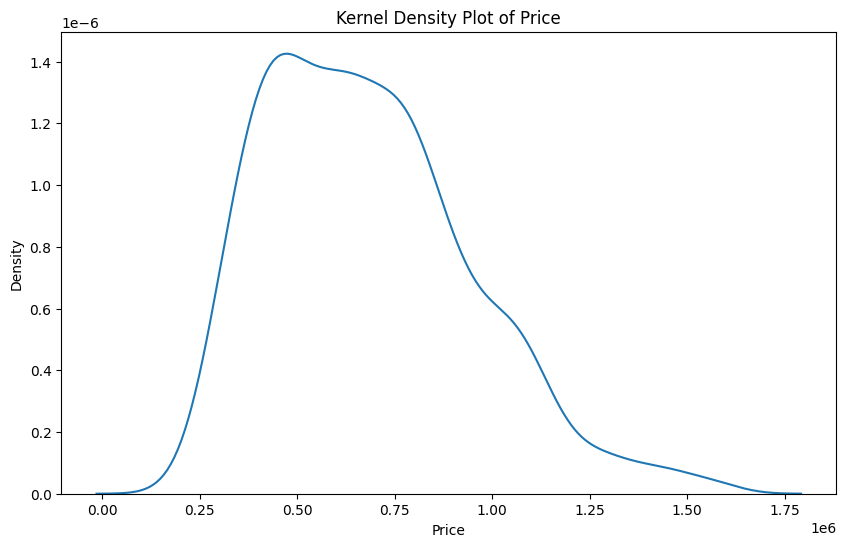

In [116]:

plt.figure(figsize=(10, 6))

# Kernel density plot for 'Price'
sns.kdeplot(data=filtered_cars, x='Price')
plt.title('Kernel Density Plot of Price')
plt.xlabel('Price')
plt.ylabel('Density')

plt.show()

### Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`).

In [117]:
makes = filtered_cars.groupby('Make').agg({
    'Price': 'mean',
})

print(makes)
makes.describe()

                       Price
Make                        
Honda          798972.602740
Hyundai        688437.500000
Maruti Suzuki  588784.982935
Other          749158.914729


/tmp/ipykernel_964/2441316249.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  makes = filtered_cars.groupby('Make').agg({


,Price
count,4.000000
mean,706338.500101
std,90469.037214
min,588784.982935
25%,663524.370734
50%,718798.207364
75%,761612.336731
max,798972.602740


### Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general? ###

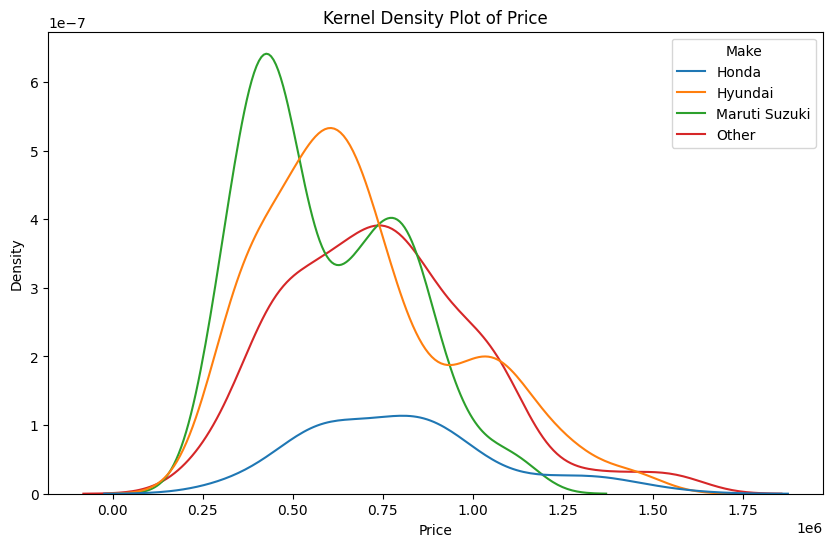

In [118]:
plt.figure(figsize=(10, 6))

# Kernel density plot for 'Price' by make
sns.kdeplot(data=filtered_cars, x='Price', hue = 'Make')
plt.title('Kernel Density Plot of Price')
plt.xlabel('Price')
plt.ylabel('Density')

plt.show()

From the grouped KDE graph, honda seems to be the most expensive

The majority of prices seem to be in between 25,000 and 75,000

### 2.3 Split the data into an 80% training set and 20% testing set

In [119]:
# split my code in to train and test
x = filtered_cars.drop(columns = 'Price')
y = filtered_cars['Price']

x_train, x_test, y_train, y_test = tts(x, y, random_state = 25, test_size = 0.2)

### 2.4 Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [120]:
model = LinearRegression()

model.fit(x_train[['Make_Year', 'Mileage_Run', 'Seating_Capacity']], y_train)

LinearRegression()

In [121]:
ypred_train = model.predict(x_train[['Make_Year', 'Mileage_Run', 'Seating_Capacity']])

r2 = r2_score(y_train, ypred_train)
print("R^2:", round(r2, 3))

mse = mean_squared_error(y_train, ypred_train)
rmse = mse ** 0.5
print("RMSE:", round(rmse, 3))


R^2: 0.34
RMSE: 214216.343


In [122]:
ypred_test = model.predict(x_test[['Make_Year', 'Mileage_Run', 'Seating_Capacity']])

r2 = r2_score(y_test, ypred_test)
print("R^2:", round(r2, 3))

mse = mean_squared_error(y_test, ypred_test)
rmse = mse ** 0.5
print("RMSE:", round(rmse, 3))

R^2: 0.291
RMSE: 226404.933


In [123]:
#hot one encode categorical variables
category_list = list(filtered_cars.select_dtypes('category')) 
cars_1he = pd.get_dummies(filtered_cars, columns = category_list, drop_first=True) 
cars_1he.head()

,Unnamed: 0,Make_Year,Mileage_Run,Price,Make_Hyundai,Make_Maruti Suzuki,Make_Other,Color_grey,Color_red,Color_white,...,No_of_Owners_2nd,No_of_Owners_3rd,Seating_Capacity_5,Seating_Capacity_7,Seating_Capacity_8,Fuel_Type_petrol,Fuel_Type_petrol+cng,Transmission_6-Speed,Transmission_Other,Transmission_Type_Manual
0,1,2017,0.442111,657000,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,2,2016,0.195044,682000,True,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
2,3,2019,0.288916,793000,False,False,False,False,False,True,...,True,False,True,False,False,True,False,False,False,True
3,4,2017,0.351329,414000,False,False,True,False,False,False,...,False,False,True,False,False,True,False,False,False,True
4,5,2017,0.244048,515000,True,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True


In [124]:
# split my code in to train and test, with one hot encoded variables
x = cars_1he.drop(columns = 'Price')
y = cars_1he['Price']

x_train, x_test, y_train, y_test = tts(x, y, random_state = 25, test_size = 0.2)

In [125]:
model = LinearRegression()
#Body_Type, Transmission, Make
x = x_train[[col for col in x_train.columns if 'Body_Type' in col]+
            [col for col in x_train.columns if 'Transmission' in col]+
            [col for col in x_train.columns if 'Make' in col]]
y = y_train

model.fit(x, y)

LinearRegression()

In [126]:
x1 = x_test[[col for col in x_train.columns if 'Body_Type' in col]+
            [col for col in x_train.columns if 'Transmission' in col]+
            [col for col in x_train.columns if 'Make' in col]]
y_pred = model.predict(x1)

r2 = r2_score(y_test, y_pred)
print("R^2:", round(r2, 3))

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print("RMSE:", round(rmse, 3))


R^2: 0.689
RMSE: 149850.601


In this case, the hot one encoded trained model performs better on the test data

In [127]:
#now with both categorical and numerical
model = LinearRegression()
x = x_train[['Make_Year', 'Mileage_Run']+
            [col for col in x_train.columns if 'Body_Type' in col]+
            [col for col in x_train.columns if 'Transmission' in col]+
            [col for col in x_train.columns if 'Make' in col]]
y = y_train

model.fit(x, y)

LinearRegression()

In [128]:
x1 = x_test[['Make_Year', 'Mileage_Run']+
            [col for col in x_train.columns if 'Body_Type' in col]+
            [col for col in x_train.columns if 'Transmission' in col]+
            [col for col in x_train.columns if 'Make' in col]]
y_pred = model.predict(x1)

r2 = r2_score(y_test, y_pred)
print("R^2:", round(r2, 3))

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print("RMSE:", round(rmse, 3))

R^2: 0.689
RMSE: 150055.438


This model did not perform quite as well as the one with only categorical variables.

### 2.5 Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [129]:
from sklearn.preprocessing import PolynomialFeatures

In [130]:
X = filtered_cars[['Make_Year', 'Mileage_Run']]
y = filtered_cars['Price']
X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=42)
        
def poly_run (deg):
    poly = PolynomialFeatures(degree = deg, include_bias= False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)
    r2 = r2_score(y_test, y_pred)
    print("R^2:", round(r2, 3))
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    print("RMSE:", round(rmse, 3))
        
for deg in [1,2,3,4,5,6,7,8,9,10]:
    poly_run(deg)

R^2: 0.258
RMSE: 223201.738
R^2: 0.269
RMSE: 221474.225
R^2: 0.268
RMSE: 221594.622
R^2: 0.268
RMSE: 221594.636
R^2: 0.268
RMSE: 221594.93
R^2: 0.268
RMSE: 221595.495
R^2: 0.268
RMSE: 221596.352
R^2: 0.268
RMSE: 221597.526
R^2: 0.268
RMSE: 221599.048
R^2: 0.268
RMSE: 221600.956


**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

In [131]:
honey = pd.read_csv('/workspaces/DS-3021/data/honey_purity_dataset.csv')
honey.head()

,CS,Density,WC,pH,EC,F,G,Pollen_analysis,Viscosity,Purity,Price
0,2.81,1.75,23.04,6.29,0.76,39.02,33.63,Blueberry,4844.50,0.68,645.24
1,9.47,1.82,17.50,7.20,0.71,38.15,34.41,Alfalfa,6689.02,0.89,385.85
2,4.61,1.84,23.72,7.31,0.80,27.47,34.36,Chestnut,6883.60,0.66,639.64
3,1.77,1.40,16.61,4.01,0.78,31.52,28.15,Blueberry,7167.56,1.00,946.46
4,6.11,1.25,19.63,4.82,0.90,29.65,42.52,Alfalfa,5125.44,1.00,432.62


In [132]:
pollens = honey.groupby('Pollen_analysis').agg({
    'Price': 'mean',
    'Purity': 'mean'
})

pollens = pollens.sort_values(by = 'Price')
pollens

,Price,Purity
Pollen_analysis,,
Clover,173.729015,0.823283
Orange Blossom,207.136451,0.824386
Wildflower,265.813135,0.826286
Alfalfa,356.417632,0.824244
Acacia,446.981373,0.822967
Lavender,497.412851,0.824137
Buckwheat,564.114152,0.824577
Eucalyptus,571.978726,0.823987
Borage,613.873783,0.824468


This suggests that the type of pollen has a big impact on the price of honey, but not not the purity. I was curious to see how a regression with many categories would work, so I tried it out:

In [177]:
honey['Pollen_analysis'] = honey['Pollen_analysis'].astype('category')

honey_1he = pd.get_dummies(honey, columns = ['Pollen_analysis'], drop_first=True)

x = honey_1he[[col for col in honey_1he.columns if 'Pollen' in col]]
y = honey_1he['Price']

xtrain, xtest, ytrain, ytest = tts(x, y, random_state= 33, test_size=0.2)

model = LinearRegression()
model.fit(xtrain, ytrain)

LinearRegression()

In [178]:
price_pred = model.predict(xtest)
r2 = r2_score(ytest, price_pred)
print('R2: ', r2)
mse = mean_squared_error(ytest, price_pred)
print('RMSE: ', mse * 0.5)

R2:  0.7927763533292356
RMSE:  5668.2135957025275


In [133]:
#I'm interested in density, purity, pH, and fructose level (F)
honey_new = honey[['Density', 'Purity', 'pH', 'F', 'Price']]
honey_new.describe()

,Density,Purity,pH,F,Price
count,247903.000000,247903.000000,247903.000000,247903.000000,247903.000000
mean,1.535523,0.824471,4.996047,34.970573,594.807644
std,0.187824,0.139417,1.444060,8.655898,233.627972
min,1.210000,0.610000,2.500000,20.000000,128.720000
25%,1.370000,0.660000,3.750000,27.460000,433.000000
50%,1.540000,0.820000,4.990000,34.970000,612.960000
75%,1.700000,0.970000,6.250000,42.470000,770.220000
max,1.860000,1.000000,7.500000,50.000000,976.690000


In [ ]:
num_list = ['Density', 'Purity', 'pH', 'F']

#standardize
for cat in num_list:
    honey_new.loc[:, cat] = MinMaxScaler().fit_transform(honey_new[[cat]])

num_list = ['Density', 'Purity', 'pH', 'F']

honey_new

/tmp/ipykernel_964/2543592541.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[[0.83076923]
 [0.93846154]
 [0.96923077]
 ...
 [0.43076923]
 [0.81538462]
 [1.        ]]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  honey_new.loc[:, cat] = MinMaxScaler().fit_transform(honey_new[[cat]])


,Density,Purity,pH,F,Price
0,0.830769,0.179487,0.758,0.634000,645.24
1,0.938462,0.717949,0.940,0.605000,385.85
2,0.969231,0.128205,0.962,0.249000,639.64
3,0.292308,1.000000,0.302,0.384000,946.46
4,0.061538,1.000000,0.464,0.321667,432.62
...,...,...,...,...,...
247898,0.123077,1.000000,0.464,0.536667,754.98
247899,0.707692,1.000000,0.482,0.371667,543.41
247900,0.430769,0.076923,0.638,0.820000,615.46
247901,0.815385,0.923077,0.862,0.906333,949.32


In [156]:
#create a function for quick regression testing with different variables
def honey_reg(xvar, yvar):
    #partition
    #x=honey_new.drop('Price', axis=1)
    x=honey_new[[xvar]]
    y=honey_new[yvar]

    x_train, x_test, y_train, y_test = tts(x, y, random_state = 12, test_size = 0.2)
    model = LinearRegression()
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    print(f"Regressing {yvar} on {xvar}:")
    
    r2 = r2_score(y_train, train_pred)
    print("Train R^2:", round(r2, 3))
    mse = mean_squared_error(y_train, train_pred)
    rmse = mse ** 0.5
    print("Train RMSE:", round(rmse, 3))

    r2_test = r2_score(y_test, test_pred)
    print("Test R^2:", round(r2_test, 3))
    mse_test = mean_squared_error(y_test, test_pred)
    rmse_test = mse_test ** 0.5
    print("Train RMSE:", round(rmse_test, 3), '\n')


In [160]:
honey_reg('Density', 'Price')
honey_reg('pH', 'Price')
honey_reg('F', 'Price')
honey_reg('Purity', 'Price')

Regressing Price on Density:
Train R^2: 0.002
Train RMSE: 233.288
Test R^2: 0.003
Train RMSE: 233.496 

Regressing Price on pH:
Train R^2: 0.01
Train RMSE: 232.384
Test R^2: 0.01
Train RMSE: 232.663 

Regressing Price on F:
Train R^2: 0.0
Train RMSE: 233.565
Test R^2: 0.0
Train RMSE: 233.875 

Regressing Price on Purity:
Train R^2: 0.187
Train RMSE: 210.541
Test R^2: 0.186
Train RMSE: 211.022 



In [ ]:
#train model with density, pH, purity, and fructose content
x=honey_new.drop('Price', axis=1)
y=honey_new['Price']

x_train, x_test, y_train, y_test = tts(x, y, random_state = 12, test_size = 0.2)
model = LinearRegression()
model.fit(x_train, y_train)

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)
    
r2 = r2_score(y_train, train_pred)
print("Train R^2:", round(r2, 3))
mse = mean_squared_error(y_train, train_pred)
rmse = mse ** 0.5
print("Train RMSE:", round(rmse, 3))

r2_test = r2_score(y_test, test_pred)
print("Test R^2:", round(r2_test, 3))
mse_test = mean_squared_error(y_test, test_pred)
rmse_test = mse_test ** 0.5
print("Train RMSE:", round(rmse_test, 3), '\n')

# Inspect feature coefficients to see what's the most impactful
coefficients = pd.DataFrame(model.coef_, x.columns, columns=['Coefficient'])
print(coefficients)

Train R^2: 0.187
Train RMSE: 210.541
Test R^2: 0.186
Train RMSE: 211.018 

         Coefficient
Density    -1.017989
Purity    282.566994
pH         -0.836200
F          -0.688707


In [171]:
#let's see what a regression of price on pollen type AND purity

x = honey_1he[['Purity']+[col for col in honey_1he.columns if 'Pollen' in col]]
y = honey_1he['Price']

xtrain, xtest, ytrain, ytest = tts(x, y, random_state= 34, test_size=0.2)

model = LinearRegression()
model.fit(xtrain, ytrain)

LinearRegression()

In [174]:
price_pred = model.predict(xtrain)
r2 = r2_score(ytrain, price_pred)
print('Train R2: ', r2)
mse = mean_squared_error(ytrain, price_pred)
print('Train RMSE: ', mse * 0.5)

price_test = model.predict(xtest)
r2test = r2_score(ytest, price_test)
print('Test R2: ', r2test)
msetest = mean_squared_error(ytest, price_test)
print('Test RMSE: ', msetest * 0.5)

Train R2:  0.9772084885485719
Train RMSE:  622.6372308277616
Test R2:  0.9768437698668205
Test RMSE:  629.3360518380522


The model that performed best was when I regressed Price on pollen type and purity, because each of those were a pretty solid predictor individually, and accuracy increased when my model considered both. 

In my various regressions, I learned that fructose content, density, and pH are very poor predictors of the price of a given honey- their r squared values were very small.

:::{important}
### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it here

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:
:::

In [175]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 
#1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

NameError: name 'Y' is not defined

:::{tip}
### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 

:::
